# Choosing a sampler: algorithms, combinations, and the knobs

The earlier tutorials introduced each algorithm on its own terms. This one
asks the question a user actually faces: **which of them do I need, in what
proportions, and what happens if I pick wrong?**

Three algorithms update the spin configuration, and they are not
interchangeable — each can move some things and not others:

| algorithm | moves | cannot move |
|---|---|---|
| `RWMH` on `sites` | one spin to a nearby free site | the number of spins |
| `RJMCMC` | the number of spins, by birth and death | a spin to an arbitrary new site |
| `ParallelTempering` | configurations across barriers, via hot replicas | anything its *inner* schedule does not |
| `RWMH` on `lam` etc. | one continuous parameter | the configuration |

`HybridDriver` cycles them in whatever proportions you specify. Everything
below is about what those proportions cost and buy.

The headline result is not the obvious one: **adding more algorithms made the
sampler worse.** §6 works out why.

In [1]:
import sys
import time
from itertools import pairwise
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RJMCMC,
    RWMH,
    AnalyticCCE1,
    BirthDeathKernel,
    ContinuousReflected,
    DiscreteLatticeWalk,
    Experiment,
    ExperimentSet,
    GaussianL2,
    HybridDriver,
    NeighborIndex,
    ParallelTempering,
    ParameterBlock,
    Proposal,
    Schedule,
    SiteTable,
    State,
    Step,
    StretchedExponential,
    Target,
    Trace,
    simulate_dataset,
)
from nuclear_spin_recovery.post import (
    couplings,
    matches,
    predictive_signals,
    residual_distribution,
)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

## 0. One problem, held fixed

Every configuration below sees the **same** truth, the same data, the same
starting state and the same step budget. Only the schedule changes.

Two fairness caveats, stated up front because they shape how the table should
be read:

1. **A step is not a unit of work.** One tempered step advances $J$ replicas,
   so a `PT` configuration does roughly six times the arithmetic per step at
   $J = 6$. Wall-clock is reported alongside, and the honest comparison is
   whichever one your cluster allocation actually bills you for.
2. **One seed is an anecdote.** The comparison is repeated over three seeds
   and the median reported, which is still thin — the test ladder's T4 rung
   asserts on pooled runs precisely because tempering's benefit turned out to
   be strongly seed-dependent.

In [2]:
DATA_NOISE, LIK_SIGMA, LAM = 0.002, 0.02, 3e-3
TAU = np.linspace(0.0, 8e-3, 250, endpoint=False) + 8e-3 / 250
K_MAX, N_TOTAL, SEEDS = 32, 2000, (17, 23, 41)

full_table = SiteTable.from_ivady_file(REPO / "nv-2.txt", strong_thresh=750.0,
                                       weak_thresh=5.0)
keep = np.hypot(full_table.a_par, full_table.a_perp) >= 100.0
table = SiteTable(
    distance=full_table.distance[keep], positions=full_table.positions[keep],
    a_par=full_table.a_par[keep], a_perp=full_table.a_perp[keep],
    isotope=full_table.isotope[keep], gyro=full_table.gyro[keep],
)
model = AnalyticCCE1(StretchedExponential())


def make_state(sites, *, lam=LAM, sigma=LIK_SIGMA):
    return State.from_sites(
        np.sort(np.asarray(list(sites), dtype=int)),
        n_sites=len(table), n_exp=1, lam=np.array([[lam]]),
        n_stretch=np.array([[1.0]]), sigma=np.array([[sigma]]), k_max=K_MAX,
    )


true_sites = np.sort(np.random.default_rng(7).choice(len(table), 6, replace=False))
blank = ExperimentSet([Experiment(tau=TAU, n_pulses=16, b_z=311.0)])
data = simulate_dataset(make_state(true_sites, sigma=DATA_NOISE), blank, table,
                        model, sigma=DATA_NOISE, rng=np.random.default_rng(11))
target = Target(data, model, GaussianL2(), table)
obs = data.data_all

start_sites = np.sort(np.random.default_rng(31).choice(len(table), 3, replace=False))
print(f"truth : k = {len(true_sites)}")
print(f"start : k = {len(start_sites)}, lambda held at the true value")
print(f"budget: {N_TOTAL} steps per configuration, seeds {SEEDS}")

truth : k = 6
start : k = 3, lambda held at the true value
budget: 2000 steps per configuration, seeds (17, 23, 41)


## 1. The knobs

Everything below is a user choice, not a property of the model. Collected here
because the rest of the notebook is an argument about how much these matter.

In [3]:
WALK_RADIUS = 6.0      # Angstrom a spin may hop; above the 1.54 A nearest neighbour
N_REPLICAS = 6         # rungs in the tempering ladder; beta_j = 2^-j
BIRTH_PROB = 0.5       # probability RJMCMC proposes a birth rather than a death
LAM_RADIUS = 2e-4      # ms; width of the continuous lambda walk

neighbors = NeighborIndex(table.positions, radius=WALK_RADIUS)
walk = DiscreteLatticeWalk(neighbors)


def sites_block(n):
    return Step(RWMH(ParameterBlock("sites"), walk), n)


def rjmcmc_block(n, k_max=K_MAX, birth_prob=BIRTH_PROB):
    return Step(RJMCMC(ParameterBlock("sites"),
                       BirthDeathKernel(k_max=k_max, birth_prob=birth_prob)), n)


def pt_block(n, n_replicas=N_REPLICAS):
    return Step(ParallelTempering(Schedule([sites_block(1)]),
                                  n_replicas=n_replicas), n)


def lam_block(n, proposal=None):
    proposal = proposal or ContinuousReflected(radius=LAM_RADIUS, lower=5e-4,
                                               upper=2e-2)
    return Step(RWMH(ParameterBlock("lam"), proposal), n)


print(f"neighbour radius {WALK_RADIUS} A  ->  "
      f"{np.mean([neighbors.neighbors(s).size for s in range(len(table))]):.0f} "
      f"candidate sites per hop")

neighbour radius 6.0 A  ->  44 candidate sites per hop


## 2. Seven schedules

Three algorithms alone, the three pairs, and all three together. The step
counts inside each schedule are block lengths per cycle; the total budget is
the same for all seven.

In [4]:
CONFIGS = {
    "RWMH only":     Schedule([sites_block(50)]),
    "RJMCMC only":   Schedule([rjmcmc_block(50)]),
    "PT only":       Schedule([pt_block(50)]),
    "sites + RJMCMC": Schedule([sites_block(50), rjmcmc_block(50)]),
    "sites + PT":    Schedule([sites_block(50), pt_block(50)]),
    "RJMCMC + PT":   Schedule([rjmcmc_block(50), pt_block(50)]),
    "all three":     Schedule([sites_block(40), rjmcmc_block(30), pt_block(50)]),
}
for name, sched in CONFIGS.items():
    print(f"{name:16s} {len(sched)} block(s), {sched.steps_per_cycle:3d} steps per cycle")

RWMH only        1 block(s),  50 steps per cycle
RJMCMC only      1 block(s),  50 steps per cycle
PT only          1 block(s),  50 steps per cycle
sites + RJMCMC   2 block(s), 100 steps per cycle
sites + PT       2 block(s), 100 steps per cycle
RJMCMC + PT      2 block(s), 100 steps per cycle
all three        3 block(s), 120 steps per cycle


In [15]:
def run(schedule, seed, n_total=N_TOTAL, state=None):
    trace = Trace(n_sites=len(table), k_max=K_MAX, n_exp=1)
    t0 = time.time()
    HybridDriver(schedule).run(state or make_state(start_sites), target,
                               np.random.default_rng(seed), n_total=n_total,
                               trace=trace)
    return trace, time.time() - t0


def residual_curve(trace, stride=10):
    predictive = predictive_signals(trace, data, table, model, stride=stride)
    return (np.arange(0, len(trace), stride),
            residual_distribution(obs, predictive, DATA_NOISE))


results = {}
for name, schedule in CONFIGS.items():
    per_seed = []
    for seed in SEEDS:
        trace, elapsed = run(schedule, seed)
        steps, curve = residual_curve(trace)
        k = np.asarray(trace.k)
        per_seed.append({
            "trace": trace, "steps": steps, "curve": curve, "time": elapsed,
            "best": float(curve.min()),
            "k_mode": int(np.bincount(k[len(k) // 2:]).argmax()),
            "k_moved": bool(np.ptp(k) > 0),
        })
    results[name] = per_seed
    print(f"{name:16s} done ({sum(r['time'] for r in per_seed):5.1f} s total)")

RWMH only        done (  4.8 s total)
RJMCMC only      done (  4.8 s total)
PT only          done ( 29.7 s total)
sites + RJMCMC   done (  4.8 s total)
sites + PT       done ( 17.1 s total)
RJMCMC + PT      done ( 17.1 s total)
all three        done ( 14.7 s total)


## 3. The comparison

In [16]:
print(f"{'configuration':16s} {'best σ per seed':>24} {'median':>8} "
      f"{'k mode':>14} {'s/1000 steps':>13}")
for name, runs in results.items():
    best = [r["best"] for r in runs]
    kmodes = [r["k_mode"] for r in runs]
    rate = 1000 * np.mean([r["time"] for r in runs]) / N_TOTAL
    print(f"{name:16s} {[round(b, 2) for b in best]!s:>24} "
          f"{np.median(best):8.2f} {kmodes!s:>14} {rate:13.1f}")
print(f"\ntruth k = {len(true_sites)}; a residual of 1 σ means the fit reaches the noise")

configuration             best σ per seed   median         k mode  s/1000 steps
RWMH only           [38.03, 38.03, 26.93]    38.03      [3, 3, 3]           0.8
RJMCMC only           [7.49, 10.61, 8.04]     8.04      [6, 7, 7]           0.8
PT only             [27.73, 38.03, 27.73]    27.73      [3, 3, 3]           4.9
sites + RJMCMC       [18.6, 10.61, 10.61]    10.61      [8, 7, 7]           0.8
sites + PT          [27.73, 38.03, 27.73]    27.73      [3, 3, 3]           2.8
RJMCMC + PT            [7.49, 0.92, 0.92]     0.92      [6, 6, 6]           2.9
all three            [7.49, 10.61, 10.61]    10.61      [6, 7, 7]           2.5

truth k = 6; a residual of 1 σ means the fit reaches the noise


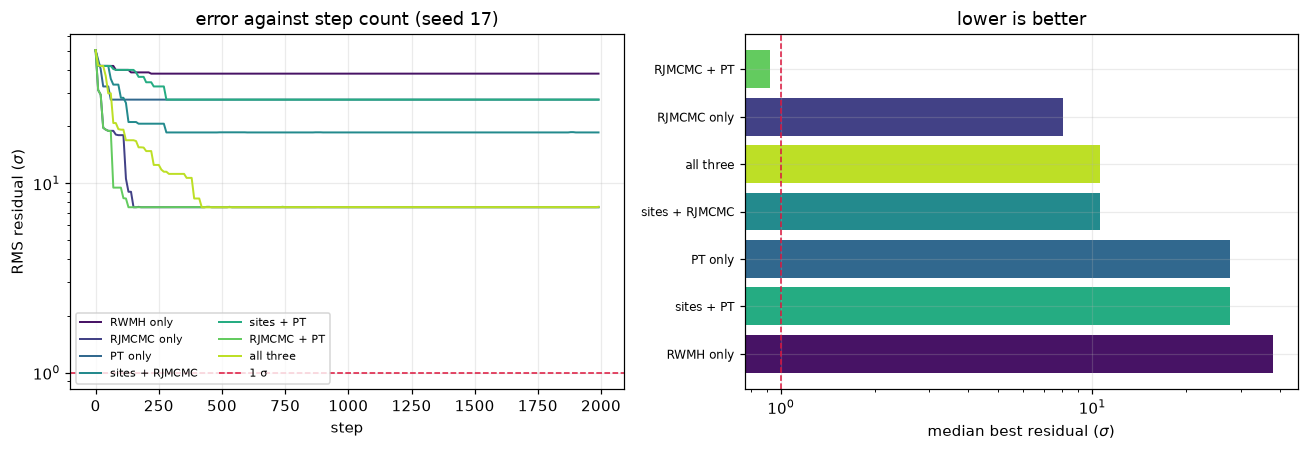

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
palette = plt.cm.viridis(np.linspace(0.05, 0.9, len(CONFIGS)))
for (name, runs), colour in zip(results.items(), palette, strict=True):
    ax1.plot(runs[0]["steps"], runs[0]["curve"], lw=1.3, color=colour, label=name)
ax1.axhline(1.0, color="crimson", ls="--", lw=1, label="1 σ")
ax1.set_yscale("log")
ax1.set_xlabel("step")
ax1.set_ylabel(r"RMS residual ($\sigma$)")
ax1.set_title(f"error against step count (seed {SEEDS[0]})")
ax1.legend(fontsize=7, ncol=2)

medians = [np.median([r["best"] for r in runs]) for runs in results.values()]
order = np.argsort(medians)[::-1]
names = np.array(list(results))[order]
ax2.barh(np.arange(len(names)), np.array(medians)[order],
         color=[palette[list(results).index(n)] for n in names])
ax2.axvline(1.0, color="crimson", ls="--", lw=1)
ax2.set_yticks(np.arange(len(names)))
ax2.set_yticklabels(names, fontsize=8)
ax2.set_xscale("log")
ax2.set_xlabel(r"median best residual ($\sigma$)")
ax2.set_title("lower is better")
plt.tight_layout()

## 4. What the table says

**Dimension is the binding constraint.** Every configuration without `RJMCMC`
is stuck at the starting $k$ and never gets near the noise, however long it
runs and whatever else is added. The starting configuration had three spins
and the truth has six; no amount of moving three spins around fixes that.

**Tempering helps, but cannot substitute.** `PT only` beats `RWMH only` — the
ladder does find better three-spin configurations — and both remain far from a
fit. Adding tempering to a sampler that cannot change dimension buys a better
answer to the wrong question.

**The pair beats every single algorithm, and beats all three together.**

## 5. What the sampler is actually selecting for

Every curve above is a residual, and that is not a presentation choice. The
likelihood sees exactly one thing — the difference between the predicted and
the measured signal. It never sees a site index, a distance from the NV, or a
spin count.

So the posterior over *configurations* is not something the sampler aims at.
It is a shadow cast by agreement in signal space, and it is worth seeing how
indirect that is.

### 5.1 The signal is what converges

Four checkpoints along one chain. At each, the best configuration found so far
— the MAP draw — is forward-modelled and drawn against the truth.

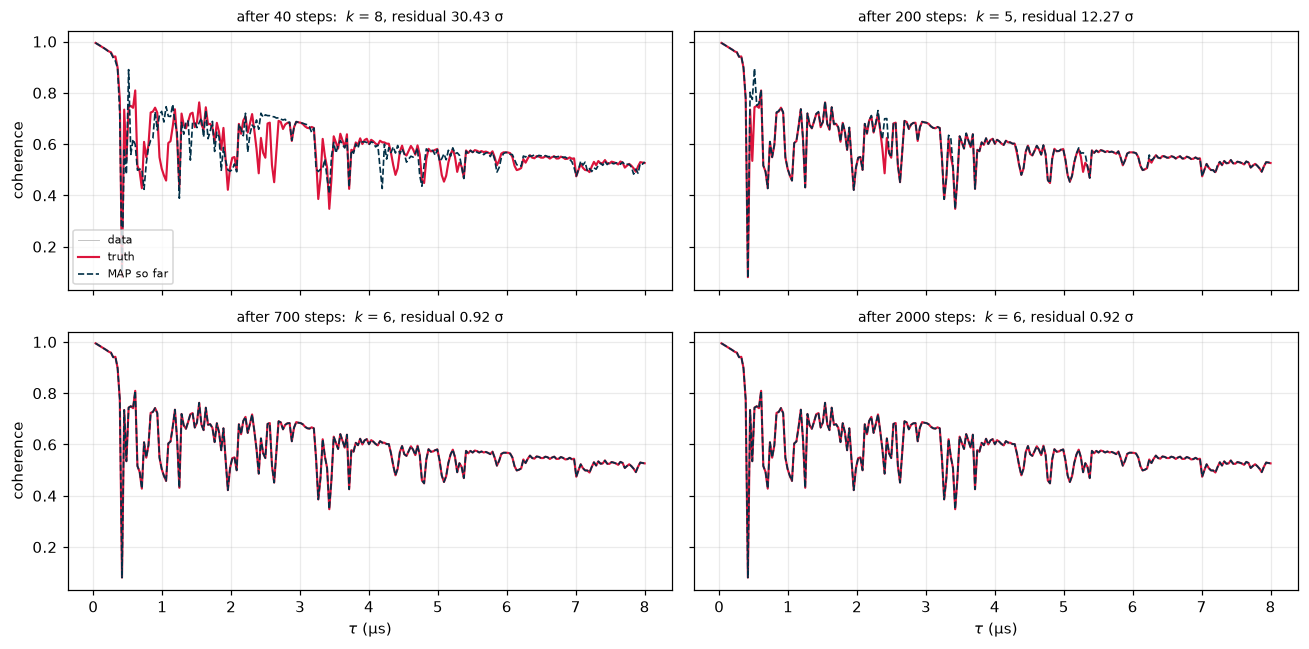

In [18]:
from nuclear_spin_recovery import simulate_coherence

demo = results["RJMCMC + PT"][1]["trace"]      # seed 23
truth_signal = simulate_coherence(make_state(true_sites), data, table, model)
CHECKPOINTS = (40, 200, 700, len(demo))


def map_state_upto(trace, upto):
    """The highest-log-probability draw among the first ``upto`` steps."""
    j = int(np.argmax(np.asarray(trace.log_prob)[:upto]))
    k = int(trace.k[j])
    return j, make_state(trace.site_idx[j, :k])


fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)
for ax, upto in zip(axes.ravel(), CHECKPOINTS, strict=True):
    j, state = map_state_upto(demo, upto)
    signal = simulate_coherence(state, data, table, model)
    res = float(np.sqrt(np.mean((obs - signal) ** 2)) / DATA_NOISE)
    ax.plot(TAU * 1e3, obs, lw=0.6, color="0.75", label="data")
    ax.plot(TAU * 1e3, truth_signal, lw=1.4, color="crimson", label="truth")
    ax.plot(TAU * 1e3, signal, lw=1.1, color="#023047", ls="--", label="MAP so far")
    ax.set_title(f"after {upto} steps:  $k$ = {int(demo.k[j])}, "
                 f"residual {res:.2f} σ", fontsize=9)
axes[0, 0].legend(fontsize=7, loc="lower left")
for ax in axes[1]:
    ax.set_xlabel(r"$\tau$ (µs)")
for ax in axes[:, 0]:
    ax.set_ylabel("coherence")
plt.tight_layout()

The dashed curve walks onto the red one. Nothing in that process referred to
where the spins are — only to how far apart the two curves were.

### 5.2 The objective *is* the residual, exactly

`GaussianL2` is

$$\log L = -\frac{1}{2\sigma^2}\sum_j (d_j - f_j)^2
         = -\frac{n}{2\sigma^2}\,\big(\text{RMS residual}\big)^2 ,$$

so the log-posterior is a deterministic function of the residual and of
nothing else. Pooling every draw from all seven configurations, that shows up
as a curve with no scatter at all — not a correlation, an identity.

In [19]:
pooled_res, pooled_logp, pooled_det, pooled_k = [], [], [], []
reference = list(zip(table.a_par[true_sites], table.a_perp[true_sites], strict=True))
for runs in results.values():
    for run_result in runs:                      # every configuration, every seed
        trace, curve = run_result["trace"], run_result["curve"]
        for i, j in enumerate(range(0, len(trace), 10)):
            k = int(trace.k[j])
            found = couplings(table, trace.site_idx[j, :k])
            pooled_res.append(curve[i])
            pooled_logp.append(float(trace.log_prob[j]))
            pooled_det.append(np.mean([matches(r, found) for r in reference]))
            pooled_k.append(k)
pooled_res = np.array(pooled_res); pooled_logp = np.array(pooled_logp)
pooled_det = np.array(pooled_det); pooled_k = np.array(pooled_k)

predicted = -0.5 * len(obs) * (pooled_res * DATA_NOISE) ** 2 / LIK_SIGMA ** 2
print(f"{len(pooled_res)} pooled draws, residual "
      f"{pooled_res.min():.2f} to {pooled_res.max():.2f} σ")
print(f"max |log L  -  the closed form above| = "
      f"{np.max(np.abs(pooled_logp - predicted)):.2e}")

4200 pooled draws, residual 0.92 to 50.54 σ
max |log L  -  the closed form above| = 1.14e-12


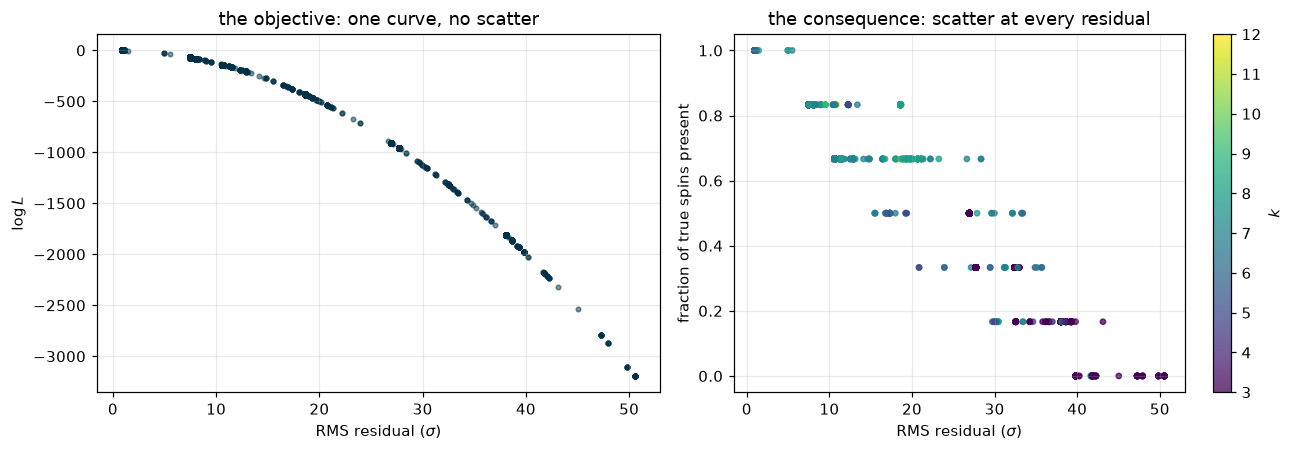

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.scatter(pooled_res, pooled_logp, s=9, color="#023047", alpha=0.5)
ax1.set_xlabel(r"RMS residual ($\sigma$)")
ax1.set_ylabel(r"$\log L$")
ax1.set_title("the objective: one curve, no scatter")

sc = ax2.scatter(pooled_res, pooled_det, s=12, c=pooled_k, cmap="viridis",
                 alpha=0.75)
ax2.set_xlabel(r"RMS residual ($\sigma$)")
ax2.set_ylabel("fraction of true spins present")
ax2.set_title("the consequence: scatter at every residual")
ax2.set_ylim(-0.05, 1.05)
fig.colorbar(sc, ax=ax2, label="$k$")
plt.tight_layout()

Two different pictures from the same draws.

On the left, the quantity the sampler maximises, plotted against the residual:
a single curve, agreeing with the closed form to machine precision. There is
nothing else in the objective.

On the right, the quantity we *care* about — how much of the true bath the
configuration contains — against the same residual. It is a cloud. Detection
does rise as the residual falls, and that relationship is the entire reason
this method works. But it is a statistical consequence of matching signals,
not something any move optimised.

In [21]:
print(f"{'residual band':>16} {'draws':>6} {'detection':>16} {'k range':>10}")
for lo, hi in ((0, 3), (3, 10), (10, 20), (20, 60)):
    m = (pooled_res >= lo) & (pooled_res < hi)
    if m.any():
        print(f"{f'{lo}-{hi} σ':>16} {int(m.sum()):6d} "
              f"{f'{pooled_det[m].min():.2f} to {pooled_det[m].max():.2f}':>16} "
              f"{f'{pooled_k[m].min()}-{pooled_k[m].max()}':>10}")

   residual band  draws        detection    k range
           0-3 σ    284     1.00 to 1.00        6-8
          3-10 σ    796     0.83 to 1.00        6-9
         10-20 σ   1213     0.50 to 0.83       5-12
         20-60 σ   1907     0.00 to 0.67        3-9


Read the last row of that table the other way round. Among the draws that fit
best, the spin count still ranges over several values. **Different numbers of
spins, in different places, fitting the data equally well** — and the sampler
has no basis for preferring one, because the likelihood cannot see the
difference.

### 5.3 Six spins moved, signal unchanged

The sharpest form of the point. Take the true configuration and relocate
**every one of its six spins** to a different lattice site in the same
symmetry orbit — spatially distinct positions, couplings equal to within the
DFT table's fourth decimal.

In [22]:
groups = table.symmetry_groups(tol=0.1)
swapped = [int(next(x for x in np.flatnonzero(groups == groups[s]) if x != s))
           for s in true_sites]


def residual_of(sites):
    signal = simulate_coherence(make_state(sites), data, table, model)
    return float(np.sqrt(np.mean((obs - signal) ** 2)) / DATA_NOISE)


print(f"true sites    {true_sites.tolist()}   residual {residual_of(true_sites):.4f} σ")
print(f"orbit-swapped {swapped}   residual {residual_of(swapped):.4f} σ")
print(f"\ndifference: {abs(residual_of(true_sites) - residual_of(swapped)):.5f} σ "
      f"-- about {abs(residual_of(true_sites) - residual_of(swapped)) * 100:.1f}% of one noise σ")

true sites    [94, 100, 110, 127, 146, 151]   residual 0.9222 σ
orbit-swapped [91, 99, 102, 112, 135, 157]   residual 0.9240 σ

difference: 0.00186 σ -- about 0.2% of one noise σ


Every spin is somewhere else and the signal is the same to a part in five
hundred of the noise. No amount of data at these settings separates those two
answers, and no sampler built on this likelihood could.

That is why detection is scored on couplings rather than site indices, and why
the specification's §9.1 asks two questions instead of one: whether the
forward model reproduces the data, which is what the sampler optimises, and
whether the posterior contains the true spins, which is what the optimisation
buys — indirectly, and only as well as the physics allows.

## 6. Which parameters move during which block

A `Schedule` is a systematic-scan Metropolis-within-Gibbs composition: each
block updates its own parameters and holds the rest fixed. The trace records
which sub-algorithm produced each step, so that structure is directly visible.

In [23]:
mixed = Schedule([sites_block(40), rjmcmc_block(30), pt_block(40), lam_block(30)])
mixed_trace, _ = run(mixed, seed=17, n_total=700,
                     state=make_state(start_sites, lam=8e-3))
labels = np.asarray(mixed_trace.algorithm)
print("blocks in one cycle:", [s.algorithm.label for s in mixed])
print("steps recorded per label:",
      {lab: int((labels == lab).sum()) for lab in dict.fromkeys(labels)})

blocks in one cycle: ['rwmh:sites', 'rjmcmc:sites', 'pt:sites', 'rwmh:lam']
steps recorded per label: {'rwmh:sites': 200, 'rjmcmc:sites': 150, 'pt:sites': 200, 'rwmh:lam': 150}


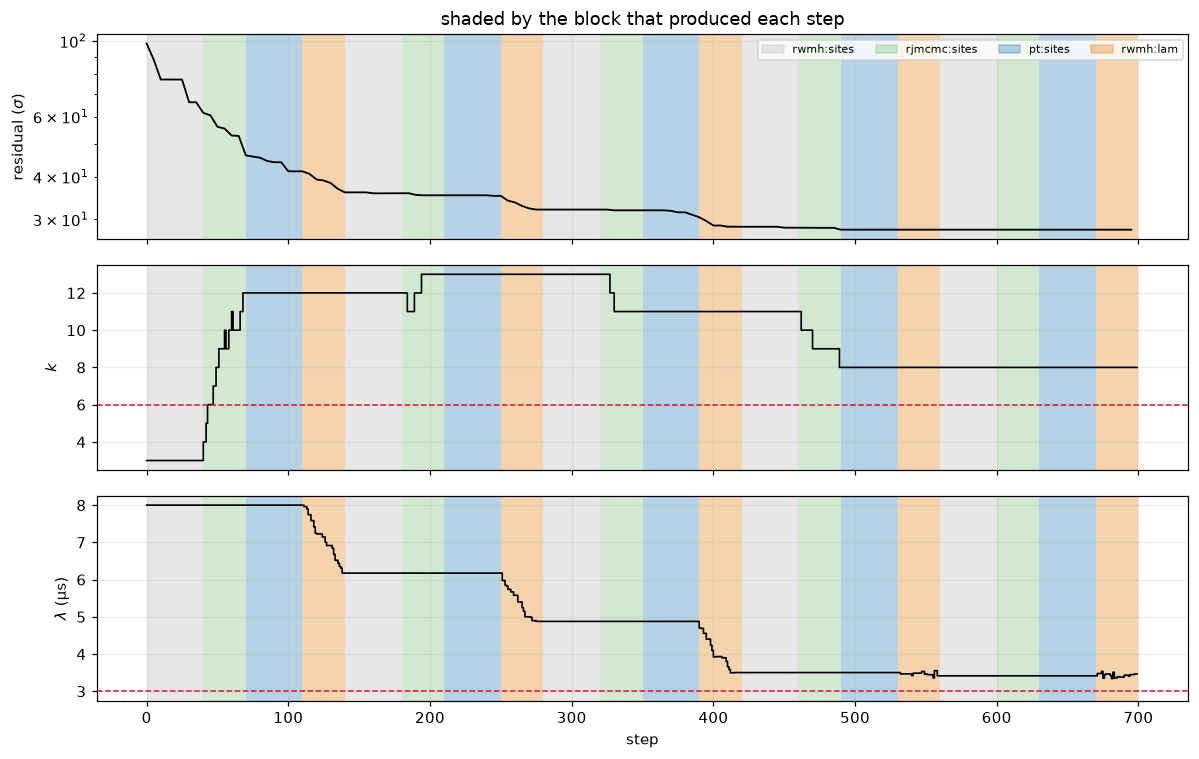

In [24]:
COLOURS = {"rwmh:sites": "#bdbdbd", "rjmcmc:sites": "#7fbf7b",
           "pt:sites": "#2c7fb8", "rwmh:lam": "#e08214"}


def shade_blocks(ax, labels):
    """Shade the background by which sub-algorithm produced each step."""
    edges = np.flatnonzero(np.r_[True, labels[1:] != labels[:-1], True])
    for lo, hi in pairwise(edges):
        ax.axvspan(lo, hi, color=COLOURS.get(labels[lo], "0.9"), alpha=0.35,
                   lw=0)


steps_m, curve_m = residual_curve(mixed_trace, stride=5)
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax in axes:
    shade_blocks(ax, labels)

axes[0].plot(steps_m, curve_m, lw=1.2, color="k")
axes[0].set_yscale("log")
axes[0].set_ylabel(r"residual ($\sigma$)")
axes[0].set_title("shaded by the block that produced each step")

axes[1].step(np.arange(len(mixed_trace)), np.asarray(mixed_trace.k), lw=1.1,
             color="k", where="post")
axes[1].axhline(len(true_sites), color="crimson", ls="--", lw=1)
axes[1].set_ylabel("$k$")

axes[2].step(np.arange(len(mixed_trace)),
             np.asarray(mixed_trace.lam)[:, 0] * 1e3, lw=1.1, color="k",
             where="post")
axes[2].axhline(LAM * 1e3, color="crimson", ls="--", lw=1)
axes[2].set_ylabel(r"$\lambda$ (µs)")
axes[2].set_xlabel("step")

handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.35)
           for c in COLOURS.values()]
axes[0].legend(handles, list(COLOURS), fontsize=7, ncol=4, loc="upper right")
plt.tight_layout()

Read the flat stretches. $k$ is a staircase that only changes under the green
`rjmcmc:sites` band; $\lambda$ is flat everywhere except the orange
`rwmh:lam` band. That is the block structure doing exactly what it claims:
each algorithm updates its own parameters and leaves the others alone.

It is also why the composition is valid. Each block leaves the target
invariant, so cycling them does too.

### A confound worth seeing

This run started with $\lambda$ deliberately wrong — 8 µs against a true 3 µs
— and the middle panel shows what that costs. $k$ climbs past the true six to
thirteen while $\lambda$ is still too long, then **sheds spins** as $\lambda$
comes down.

The spurious spins were doing $\lambda$'s job. An envelope that decays too
slowly leaves unexplained decay in the signal, and extra spins are what
`RJMCMC` has available to absorb it. Dimension and the envelope are partially
degenerate, and a chain that gets one wrong will quietly get the other wrong
to compensate.

The practical consequence: **a $k$ reported from a run whose envelope was not
also sampled is not trustworthy**, and the direction of the bias is upward.

In [ ]:
for name, block in (("k", np.asarray(mixed_trace.k)),
                    ("λ", np.asarray(mixed_trace.lam)[:, 0])):
    changed = {lab: int(np.sum((np.diff(block) != 0) & (labels[1:] == lab)))
               for lab in dict.fromkeys(labels)}
    print(f"{name:2s} changed during: " +
          ", ".join(f"{lab} {n}x" for lab, n in changed.items() if n))

## 7. Why "all three" loses to the pair

This is the result worth taking away, because it runs against the instinct
that more machinery is better.

`ParallelTempering` is not a peer of the other two — it is a *wrapper*. Its
inner schedule here is itself a `sites` RWMH, run at every rung of the ladder.
So a cycle of `sites + RJMCMC + PT` spends part of its budget walking spins at
$\beta = 1$, and then spends more budget walking the same spins at $\beta = 1$
again as rung 0 of the ladder — plus five hot rungs that actually explore.

The plain `sites` block is therefore not adding a capability. It is buying
cold-chain moves, at the price of tempered ones, out of a fixed budget.

In [ ]:
print(f"{'configuration':16s} {'cold sites steps':>18} {'tempered steps':>16} "
      f"{'median best σ':>14}")
for name in ("RJMCMC + PT", "all three"):
    sched = CONFIGS[name]
    cold = sum(s.n_steps for s in sched if s.algorithm.label == "rwmh:sites")
    hot = sum(s.n_steps for s in sched if s.algorithm.label.startswith("pt:"))
    frac = N_TOTAL / sched.steps_per_cycle
    med = np.median([r["best"] for r in results[name]])
    print(f"{name:16s} {int(cold * frac):18d} {int(hot * frac):16d} {med:14.2f}")

The lesson generalises: **check whether a block adds a capability or only
competes for budget.** A schedule is a partition of a fixed resource, and an
algorithm that duplicates what another already does inside itself is spending
that resource twice on the same move.

## 8. Writing your own proposal

`Proposal` is an ABC with one required method. Anything that returns a value
and the log of its proposal ratio composes with everything above — no sampler
changes, no special-casing.

Here is one with no physical motivation whatsoever, purely to show the seam:
sample $\lambda$ from a **discrete grid** instead of continuously.

In [ ]:
class DiscreteChoice(Proposal):
    """Draw a value uniformly from a fixed grid.

    An independence sampler: the proposal does not depend on the current
    value, so the forward and reverse densities are both 1/n and the log
    proposal ratio is exactly zero.
    """

    def __init__(self, values):
        self.values = np.asarray(values, dtype=float)
        if self.values.size < 2:
            raise ValueError("need at least two values to choose between")

    def propose(self, rng, current, occupied=None):
        return rng.choice(self.values, size=np.shape(current)), 0.0


grid = np.linspace(1e-3, 1e-2, 10)
print(f"grid (µs): {np.round(grid * 1e3, 1).tolist()}   truth {LAM * 1e3:.1f}")

trace_grid, _ = run(Schedule([lam_block(50, DiscreteChoice(grid))]), seed=3,
                    n_total=600, state=make_state(true_sites, lam=9e-3))
sampled = np.asarray(trace_grid.lam)[300:, 0]
values, counts = np.unique(np.round(sampled * 1e3, 1), return_counts=True)
print("posterior over the grid:",
      {v: int(c) for v, c in zip(values.tolist(), counts.tolist(), strict=True)})

The chain concentrates on the grid point that is the truth. Swapping a
continuous kernel for a discrete one required no change to `RWMH`, to the
driver, or to anything else — the acceptance rule only ever asked the proposal
for its ratio.

### A grid is a hyperparameter, and a bad one fails quietly

In [ ]:
coarse = np.linspace(0.0, 1.0, 11)        # ms, as a user might naively pick

# lam = 0 divides by zero in the envelope and gives exp(-inf) = 0, which is the
# correct limit -- instantaneous dephasing -- but numpy warns about it. Silenced
# here because it is expected, not because it is harmless: see below.
with np.errstate(divide="ignore"):
    trace_coarse, _ = run(Schedule([lam_block(50, DiscreteChoice(coarse))]),
                          seed=3, n_total=300,
                          state=make_state(true_sites, lam=0.5))
picked = np.asarray(trace_coarse.lam)[150:, 0]
values, counts = np.unique(np.round(picked, 2), return_counts=True)
print(f"coarse grid (ms): {np.round(coarse, 1).tolist()}")
print("posterior:", {v: int(c) for v, c in zip(values.tolist(), counts.tolist(), strict=True)})

Every point on that grid is wrong. The true $\lambda$ is 3 µs and the finest
non-zero option is 100 µs, at which the envelope barely decays at all — so the
chain settles on $\lambda = 0$, which means *instantaneous* dephasing, as the
least-bad available answer.

It reports that with total confidence and no warning. A grid that does not
bracket the truth does not fail loudly; it returns a wrong answer that looks
converged. The same is true of every other hyperparameter below.

## 9. Initialisation is a user choice too

In [ ]:
starts = {
    "from below (k=3)": make_state(start_sites),
    "from above (k=12)": make_state(
        np.random.default_rng(5).choice(len(table), 12, replace=False)),
    "at the truth": make_state(true_sites),
}
schedule = CONFIGS["RJMCMC + PT"]
print(f"{'start':20s} {'best σ':>8} {'k mode':>8}")
for label, state in starts.items():
    trace, _ = run(schedule, seed=17, n_total=1200, state=state)
    _, curve = residual_curve(trace)
    k = np.asarray(trace.k)
    print(f"{label:20s} {curve.min():8.2f} "
          f"{int(np.bincount(k[len(k) // 2:]).argmax()):8d}")
print(f"\ntruth k = {len(true_sites)}")

Starting at the truth is not cheating here — it is the control. If a sampler
started at the answer wanders away from it, the problem is the sampler or the
likelihood width, not the search.

For ensembles the policy matters more: `spread_across_k` deliberately starts
chains above *and* below, so the dimension multimodality shows up as
disagreement rather than hiding behind a shared prejudice. See the ensembles
tutorial.

## 10. The hyperparameters, collected

| knob | set by | used here | what it trades |
|---|---|---|---|
| `strong_thresh`, `weak_thresh` | `SiteTable.from_ivady_file` | 750 / 5 kHz | candidate pool size against identifiability |
| coupling cutoff | the detectable-table filter | 100 kHz | dimension identifiability against realism |
| `radius` | `NeighborIndex` | 6.0 Å | hop distance against acceptance |
| `radius` | `ContinuousReflected` | 2e-4 ms | step size against acceptance |
| `k_max` | `BirthDeathKernel` | 32 | ceiling on inferred dimension |
| `birth_prob` | `BirthDeathKernel` | 0.5 | birth/death balance (cancels in the ratio) |
| `log_prior_k` | `BirthDeathKernel` | None (uniform) | the prior on bath size |
| `n_replicas` | `ParallelTempering` | 6 | barrier crossing against cost per step |
| `betas` | `ParallelTempering` | $2^{-j}$ | swap acceptance against ladder reach |
| block lengths | `Step` | 30–50 | budget split between algorithms |
| block order | `Schedule` | — | which moves see which state |
| `sigma` | the state | 0.02 | posterior sharpness against mobility |
| initialisation | the starting `State` | $k = 3$ | which mode the chain finds |
| `n_total`, burn-in | the driver, the summary | 2000 / half | cost against convergence |

Two of these were calibrated rather than chosen — the likelihood $\sigma$ and
the detectable-table cutoff — and `docs/test-plan.md` §5 records the runs
behind both. The rest are yours.

## Where to go next

What this notebook measured, on one problem at three seeds: dimension was the
binding constraint, so nothing without `RJMCMC` came close; tempering improved
the search but could not substitute for it; and the best pair beat all three
algorithms together, because the third was competing for budget rather than
adding a capability.

None of that transfers automatically. A bath whose dimension is known would
invert the first conclusion entirely, and a rougher landscape would raise the
value of tempering. The point is the method: fix the budget, fix the seed set,
vary one thing, and read the residual against step count.

`docs/model-specification.md` §8 specifies the algorithms; `docs/test-plan.md`
§5 records every calibrated number quoted here.